Start this up before you start reading.

In [ ]:
%pip install -q qiskit qiskit-aer pylatexenc matplotlib

# 9. 2-Qubit Gate Decompositions

## Objectives
* See why *any* two-qubit gate is just single-qubit gates plus a few CNOTs
* Meet the **KAK (Weyl) decomposition** and read a gate's "interaction content"
* Predict — and verify — the exact number of CNOTs a gate costs
* Watch how the choice of native gate, and a little allowed error, change that cost

In the last lab you learned to *build* with the CNOT and SWAP gates. You also met a
loose end: a SWAP "isn't free", and on real hardware it gets transpiled into **three
CNOTs**. We never said *why three*. Today we find out — and we'll discover that **three
is the magic number** for almost every two-qubit gate you can write down.

Here is the whole story in one sentence:

<div class="alert alert-info">

Any two-qubit unitary $U$ can be written as **single-qubit gates on each wire, with a
handful of CNOTs in between** — and for a *generic* gate that handful is exactly **three**.

</div>

The single-qubit gates are "easy" (cheap, low-noise). The CNOTs are the expensive,
noisy, entangling part — so the real cost of a two-qubit gate is *how many CNOTs it
needs*. By the end of the lab you'll be able to look at any $4\times4$ unitary and call
that number before Qiskit does.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm

from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Operator, random_unitary, process_fidelity
from qiskit.circuit.library import CXGate, CZGate, iSwapGate, SwapGate, RZZGate
from qiskit.synthesis import (
    OneQubitEulerDecomposer,
    TwoQubitWeylDecomposition,
    TwoQubitBasisDecomposer,
)
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error

np.set_printoptions(suppress=True, precision=4)

# Pauli matrices, for building the "interaction core" by hand later.
X = np.array([[0, 1], [1, 0]])
Y = np.array([[0, -1j], [1j, 0]])
Z = np.array([[1, 0], [0, -1]])

# The non-local 'heart' of a two-qubit gate: exp(i (a XX + b YY + c ZZ)).
def interaction_core(a, b, c):
    return expm(1j * (a * np.kron(X, X) + b * np.kron(Y, Y) + c * np.kron(Z, Z)))

# Process fidelity to a target unitary. 1.0 == identical up to a global phase.
def gate_fidelity(circ_or_op, target):
    return process_fidelity(Operator(circ_or_op), Operator(target))

## 1. Warm-up: one qubit is already solved

Back in the 1-qubit lab you met the **ZYZ decomposition**: every single-qubit gate can
be written as

$$U = e^{i\alpha}\, R_z(\theta_2)\, R_y(\theta_1)\, R_z(\theta_0).$$

Three angles, and you can hit *any* single-qubit unitary.

Qiskit packages this up in `OneQubitEulerDecomposer`, which you use in two steps:

1. **Make one**, telling it which rotation basis you want:
   `zyz = OneQubitEulerDecomposer(basis="ZYZ")`. (Other choices exist — `"ZXZ"`, `"U"`,
   and so on — but `"ZYZ"` is the factorization written above.)
2. **Call it like a function** on a single-qubit unitary: `qc1 = zyz(U1)`. Under the
   hood it solves for the three Euler angles $(\theta_0, \theta_1, \theta_2)$ and the
   phase $\alpha$, and hands you back a small `QuantumCircuit` of `rz, ry, rz` that
   reproduces `U1`.

So the object does the trig for you; your job is to call it and then *confirm the result
really is the same gate*. The clean way to check is `Operator(qc1).equiv(U1)`: it builds
the unitary of your circuit and compares it to `U1` **up to a global phase** — that
$e^{i\alpha}$ out front is physically unobservable, so we don't want it counted as a
difference.

<b>Call `zyz` on `U1` to get a circuit, then verify it matches.</b> Two lines do it:
build `qc1 = zyz(U1)`, then print `Operator(qc1).equiv(U1)` (`True` means the
decomposition is faithful). Print `qc1.draw()` as well if you'd like to see the three
rotations and the angles it chose.

In [3]:
zyz = OneQubitEulerDecomposer(basis="ZYZ")
U1 = random_unitary(2, seed=1)

qc1 = zyz(U1)                 # a little circuit of rz, ry, rz
print(qc1.draw())
print("matches U1?", Operator(qc1).equiv(U1))

global phase: 4.9282
   ┌─────────────┐┌────────────┐┌─────────────┐
q: ┤ Rz(-2.8969) ├┤ Ry(1.1536) ├┤ Rz(-2.2253) ├
   └─────────────┘└────────────┘└─────────────┘
matches U1? True


So one qubit costs us nothing to worry about. What about *two* qubits that simply
sit side by side and never talk — a gate of the form $U_a \otimes U_b$?

First we need such a gate to hand to Qiskit. Two ingredients:

* `random_unitary(2, seed=...)` draws a Haar-random *single-qubit* gate (a $2\times2$
  unitary). It returns an `Operator`; its raw matrix is the `.data` attribute.
* `np.kron(A, B)` is the **tensor ("Kronecker") product** — it stacks two single-qubit
  matrices into the $4\times4$ that runs `A` on the top wire and `B` on the bottom,
  independently. That $A \otimes B$ is exactly a "never-talk" two-qubit gate.

To count the CNOTs we meet the two-qubit analog of `OneQubitEulerDecomposer`:
**`TwoQubitBasisDecomposer`**. You construct it with the entangling gate you want to
build *from* — here `TwoQubitBasisDecomposer(CXGate())` for a CNOT basis. Like its
one-qubit cousin you can call it on a $4\times4$ to get a whole circuit (we'll do that in
§5), but it also offers a shortcut: `.num_basis_gates(matrix)` returns *just the CNOT
count* for that matrix, without bothering to build the circuit.

<b>Build a tensor-product gate and ask how many CNOTs it needs.</b> Make two random
single-qubit gates, `np.kron` them into `U_prod`, construct a
`TwoQubitBasisDecomposer(CXGate())`, and print its `.num_basis_gates(U_prod)`.

In [4]:
# Build a "side by side" gate: two single-qubit unitaries, one per wire, that never
# interact. random_unitary(2) gives a Haar-random single-qubit gate; np.kron tensors
# them into a 4x4. Then make a CNOT-based decomposer and ask it for the CNOT count.

Ua, Ub = random_unitary(2, seed=2), random_unitary(2, seed=3)
U_prod = np.kron(Ua.data, Ub.data)
cx_dec = TwoQubitBasisDecomposer(CXGate())
print("CNOTs for a tensor-product gate:", cx_dec.num_basis_gates(U_prod))

CNOTs for a tensor-product gate: 0


Zero, of course — two qubits that never interact need no entangling gate at all.
That is the whole point: **CNOTs are the price of interaction.** The interesting
question is how many you need once the two qubits *do* talk.

## 2. Why three? A counting argument

Let's get a first estimate by counting knobs. A general two-qubit gate lives in
$SU(4)$, which has **15** real parameters — that's how many independent dials you'd need
to reach an arbitrary one. Now build an ansatz to imitate it: alternate layers of
single-qubit gates with CNOTs. With $k$ CNOTs you get $k+1$ single-qubit *layers* (one
before the first CNOT, one after each); each layer puts a single-qubit gate on both
wires, and each single-qubit gate carries $3$ angles. So one layer has
$2 \times 3 = 6$ tunable angles, and the whole $k$-CNOT circuit has $6(k+1)$ of them.
(The CNOTs themselves are fixed — they carry no parameters.)

Your first job is to turn that into code: **`param_count(k)` should return how many free
single-qubit parameters a $k$-CNOT circuit has** — i.e. the $6(k+1)$ above.

Then we want the *smallest* $k$ whose knobs could possibly cover all 15. The simplest way
to find it is to try the small cases directly: loop over $k = 0, 1, 2, 3$, compute
`param_count(k)`, and compare it to `TARGET = 15`. The first $k$ with
`param_count(k) >= TARGET` is the floor — any fewer CNOTs literally can't supply enough
dials to reach a generic gate.

<b>Fill in `param_count`, then write the loop that finds the smallest sufficient $k$.</b>

In [5]:
TARGET = 15   # real parameters in a general SU(4) gate

def param_count(k):
    # Return how many free single-qubit parameters a k-CNOT ansatz has:
    # k+1 single-qubit layers, two gates per layer, three angles per gate.
    return 6 * (k + 1)

# Loop over k = 0, 1, 2, 3, compare param_count(k) to TARGET, and print a verdict for
# each so you can read off the smallest k that has enough knobs.
for k in range(4):
    verdict = "could be enough" if param_count(k) >= TARGET else "too few knobs"
    print(f"k = {k} CNOTs -> {param_count(k):2d} params   ({verdict})")

k = 0 CNOTs ->  6 params   (too few knobs)
k = 1 CNOTs -> 12 params   (too few knobs)
k = 2 CNOTs -> 18 params   (could be enough)
k = 3 CNOTs -> 24 params   (could be enough)


<div class="alert alert-info">

**Pause and think.** Look at the parameter counts you just printed. The first $k$ whose
ansatz carries at least 15 knobs is the smallest number of CNOTs the *counting argument*
can possibly allow — read that number off your own output before going on.

Now the sharper question. A circuit needs **at least** as many free dials as the gate it
is trying to match, so "enough knobs" is plainly a *necessary* condition. But is it a
*sufficient* one? Does owning fifteen-or-more dials guarantee you can actually turn them
to reach **every** two-qubit gate — or might the geometry still block some? In other
words, is the number you just read off a true minimum, or only a lower bound?

</div>

Counting can *suggest* a number, but only an experiment can tell us whether that number
is really achievable. So let's stop arguing and measure.

<b>Try it: find the depth where the approximation becomes exact.</b> We've set up a random
$4\times4$ gate `U` and a CNOT-basis decomposer `cx_dec`. For each CNOT budget `n` — start
at $n = 0$ and climb — ask the decomposer for the best circuit that uses *exactly* `n`
CNOTs, then measure how faithful that circuit is to `U`. Watch the fidelity as `n` grows:
the smallest `n` at which it reaches $1.0$ is how many CNOTs a generic gate *actually*
needs.

* `cx_dec(U.data, _num_basis_uses=n)` builds the best circuit constrained to exactly `n`
  CNOTs — the `_num_basis_uses` knob is what pins the count.
* `gate_fidelity(circ, U)` returns $1.0$ when the circuit reproduces `U` exactly, and
  drops below $1$ when the budget was too small to reach it.

How high should you let `n` go? Lean on the lower bound from your counting argument — then
climb at least one CNOT past where you expect success, so you can watch the fidelity truly
saturate instead of guessing.

In [6]:
U = random_unitary(4, seed=5)
cx_dec = TwoQubitBasisDecomposer(CXGate())

for n in range(4):
    approx = cx_dec(U.data, _num_basis_uses=n)   # best circuit with exactly n CNOTs
    print(f"{n} CNOTs -> fidelity {gate_fidelity(approx, U):.4f}")

0 CNOTs -> fidelity 0.4729
1 CNOTs -> fidelity 0.8733
2 CNOTs -> fidelity 0.9900
3 CNOTs -> fidelity 1.0000


<div class="alert alert-success">

**What you should see**

The fidelity climbs — $0$ CNOTs is hopeless, $2$ gets *tantalizingly* close (~0.98) —
but it snaps to exactly $1.0$ **only at the third CNOT**. So the parameter count was
right that you need *at least* 2, but two-CNOT gates are a measure-zero special case;
almost every gate needs the **third** CNOT. Counting got us close; to nail the exact
answer we need a sharper tool.

</div>


## 3. The KAK (Weyl) decomposition

The sharper tool is a beautiful theorem. **Every** two-qubit gate factors as

$$U = \big(A_1 \otimes A_2\big)\; \exp\!\Big(i\,(a\,XX + b\,YY + c\,ZZ)\Big)\; \big(B_1 \otimes B_2\big),$$

where $A_i, B_i$ are single-qubit gates (the "easy" parts) and the middle exponential is
the only piece that actually entangles. All of the non-local content lives in just three
numbers $(a, b, c)$ — the **Weyl coordinates**. Two gates with the same $(a,b,c)$ are
identical up to single-qubit gates, so $(a,b,c)$ is a gate's true "interaction
fingerprint".

Qiskit computes this with `TwoQubitWeylDecomposition` (note: it lives in
`qiskit.synthesis`, not `quantum_info`). Using it is two moves:

* **Feed it a raw $4\times4$ matrix.** The constructor wants a NumPy array, not a Qiskit
  gate object — so pull the matrix out first with `.data`. Anything you can wrap in an
  `Operator` (a gate like `CXGate()`, or a whole circuit) gives you that array via
  `Operator(g).data`. So the call is
  `w = TwoQubitWeylDecomposition(Operator(g).data)`. (If you already built the gate as a
  NumPy array by hand, you can pass it straight in — it's the `.data` step that converts a
  Qiskit *object* into the array the decomposer expects.)
* **Read the coordinates off as attributes.** The returned object `w` carries the three
  numbers directly: `w.a`, `w.b`, `w.c`. (It also holds the local gates and the global
  phase, which we'll put to work in the next exercise.)

<b>Print the Weyl coordinates of the gates you already know.</b> Loop over the `gates`
dict below; for each one build `w = TwoQubitWeylDecomposition(Operator(g).data)` and print
`w.a, w.b, w.c`.

In [7]:
gates = {
    "I": Operator(np.eye(4)),
    "CNOT": CXGate(),
    "CZ": CZGate(),
    "iSWAP": iSwapGate(),
    "SWAP": SwapGate(),
}

for name, g in gates.items():
    w = TwoQubitWeylDecomposition(Operator(g).data)
    print(f"{name:6s} (a, b, c) = ({w.a:.4f}, {w.b:.4f}, {w.c:.4f})")

I      (a, b, c) = (0.0000, 0.0000, 0.0000)
CNOT   (a, b, c) = (0.7854, 0.0000, 0.0000)
CZ     (a, b, c) = (0.7854, 0.0000, 0.0000)
iSWAP  (a, b, c) = (0.7854, 0.7854, 0.0000)
SWAP   (a, b, c) = (0.7854, 0.7854, 0.7854)


Notice the landmarks (in units where $\pi/4 \approx 0.785$):

| gate | $(a, b, c)$ |
|------|-------------|
| identity | $(0, 0, 0)$ |
| CNOT, CZ | $(\pi/4, 0, 0)$ |
| iSWAP | $(\pi/4, \pi/4, 0)$ |
| SWAP | $(\pi/4, \pi/4, \pi/4)$ |

The decomposition object also hands back the four single-qubit gates ($A_i, B_i$) and a
global phase, so we can **rebuild $U$ from its pieces** and check the theorem is real,
not magic.

<b>Reconstruct $U$ from the KAK pieces and confirm it matches.</b> The object exposes
`w.a, w.b, w.c`, the local gates `w.K1l, w.K1r, w.K2l, w.K2r`, and `w.global_phase`.
Use the provided `interaction_core(a, b, c)` for the middle exponential.

In [8]:
U = random_unitary(4, seed=8)
w = TwoQubitWeylDecomposition(U.data)

core = interaction_core(w.a, w.b, w.c)
K1 = np.kron(w.K1l, w.K1r)
K2 = np.kron(w.K2l, w.K2r)
recon = np.exp(1j * w.global_phase) * (K1 @ core @ K2)
print("reconstruction matches U?", np.allclose(recon, U.data, atol=1e-8))

reconstruction matches U? True


Every two-qubit gate is a point $(a, b, c)$ in a little tetrahedron called the
**Weyl chamber**. The cell below scatters a few hundred random gates into it and marks
the landmarks. (Provided — just run it.)

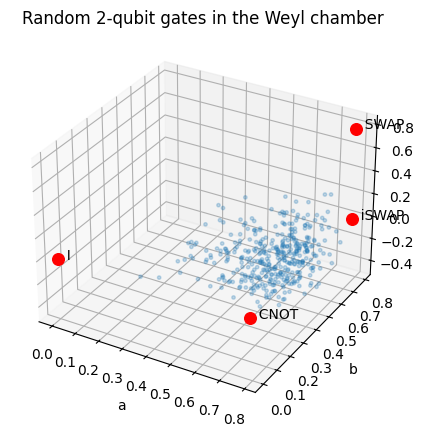

In [9]:
coords = []
for s in range(400):
    w = TwoQubitWeylDecomposition(random_unitary(4, seed=s).data)
    coords.append([w.a, w.b, w.c])
coords = np.array(coords)

fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(coords[:, 0], coords[:, 1], coords[:, 2], s=6, alpha=0.25)

landmarks = {
    "I": (0, 0, 0),
    "CNOT": (np.pi / 4, 0, 0),
    "iSWAP": (np.pi / 4, np.pi / 4, 0),
    "SWAP": (np.pi / 4, np.pi / 4, np.pi / 4),
}
for name, (a, b, c) in landmarks.items():
    ax.scatter([a], [b], [c], s=70, color="red")
    ax.text(a, b, c, "  " + name)

ax.set_xlabel("a"); ax.set_ylabel("b"); ax.set_zlabel("c")
ax.set_title("Random 2-qubit gates in the Weyl chamber")
plt.show()

## 4. Reading the CNOT count straight off the coordinates

Here is the payoff. The number of CNOTs a gate needs is fixed entirely by *where it sits
in the chamber*:

* $(0,0,0)$ — local, **0** CNOTs
* $(\pi/4, 0, 0)$ — the CNOT point exactly, **1** CNOT
* $c = 0$ (the floor of the chamber) — **2** CNOTs
* $c \ne 0$ (everywhere else) — **3** CNOTs

That last bullet is why "three is the magic number": almost every gate has $c \ne 0$.

<b>Write `cnot_count(U)` using the rules above.</b>

In [10]:
def cnot_count(U):
    # Predict the minimum CNOT count from the Weyl coordinates.
    w = TwoQubitWeylDecomposition(U)
    a, b, c = w.a, w.b, w.c
    tol = 1e-7
    if a < tol and b < tol and c < tol:
        return 0
    if abs(a - np.pi / 4) < tol and b < tol and c < tol:
        return 1
    if abs(c) < tol:
        return 2
    return 3

Now check your predictor against Qiskit's own counter, both on the named gates and
on a few hundred random ones. (Provided — run it.)

In [11]:
cx_dec = TwoQubitBasisDecomposer(CXGate())

print("named gates:  predicted | qiskit")
for name, g in gates.items():
    U = Operator(g).data
    print(f"  {name:6s} {cnot_count(U)}  |  {cx_dec.num_basis_gates(U)}")

mismatches = 0
for s in range(300):
    U = random_unitary(4, seed=s).data
    if cnot_count(U) != cx_dec.num_basis_gates(U):
        mismatches += 1
print("\nrandom-gate mismatches / 300:", mismatches)

named gates:  predicted | qiskit
  I      0  |  0
  CNOT   1  |  1
  CZ     1  |  1
  iSWAP  2  |  2
  SWAP   3  |  3

random-gate mismatches / 300: 0


And there's our loose end from last lab, tied off: **SWAP sits at
$(\pi/4, \pi/4, \pi/4)$ with $c \ne 0$, so it costs three CNOTs.** Not a quirk of the
transpiler — a fact about where SWAP lives in the chamber.

## 5. From a matrix to an actual circuit

Predicting the count is one thing; let's get the real circuit. `TwoQubitBasisDecomposer`
turns any $4\times4$ unitary into single-qubit gates plus CNOTs.

<b>Decompose a random gate, print its gate counts and fidelity, and draw it.</b>

gate counts: {'u': 8, 'cx': 3}
fidelity: 0.9999999999999996


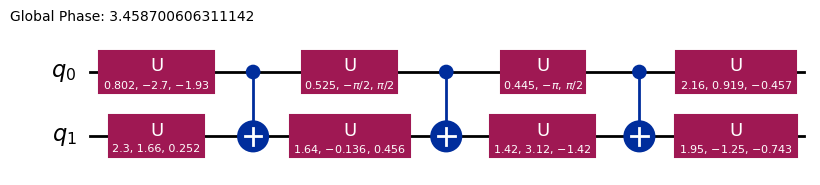

In [12]:
U = random_unitary(4, seed=42)
cx_dec = TwoQubitBasisDecomposer(CXGate())

circ = cx_dec(U.data)
print("gate counts:", dict(circ.count_ops()))
print("fidelity:", gate_fidelity(circ, U))
circ.draw("mpl")

Three CNOTs and a sprinkle of single-qubit gates, fidelity 1 — exactly as
predicted. Let's see the most famous instance of the three-CNOT rule directly.

<b>Build a SWAP out of three alternating CNOTs and verify it really is a SWAP.</b>

equals SWAP? True


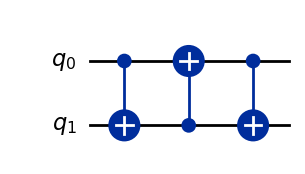

In [13]:
swap3 = QuantumCircuit(2)

swap3.cx(0, 1)
swap3.cx(1, 0)
swap3.cx(0, 1)
print("equals SWAP?", Operator(swap3).equiv(SwapGate()))
swap3.draw("mpl")

## 6. Your hardware picks the gate, the gate picks the cost

CNOT isn't the only entangling gate hardware can offer. Trapped ions like the
Mølmer–Sørensen ($\sim$ `RZZ`) interaction; some superconducting and photonic platforms
prefer the **iSWAP** family. The decomposer can target *any* two-qubit basis gate, so
the same unitary costs a different number of *native* gates depending on the machine.

<b>Decompose the same `U` into a CNOT basis, an iSWAP basis, and an `RZZ(π/2)` basis, and
compare the gate counts.</b>

In [14]:
U = random_unitary(4, seed=7)
bases = {"CNOT": CXGate(), "iSWAP": iSwapGate(), "RZZ(pi/2)": RZZGate(np.pi / 2)}

for name, bg in bases.items():
    dec = TwoQubitBasisDecomposer(bg)
    circ = dec(U.data)
    print(f"{name:10s} -> {dict(circ.count_ops())}   fidelity {gate_fidelity(circ, U):.4f}")

CNOT       -> {'u': 8, 'cx': 3}   fidelity 1.0000
iSWAP      -> {'u': 8, 'iswap': 3}   fidelity 1.0000
RZZ(pi/2)  -> {'u': 8, 'rzz': 3}   fidelity 1.0000


All three are *perfect entanglers* sitting deep in the chamber, so each can build a
generic gate in three of its own kind — but the moral from Lab 8 stands: **know your
native gate**, because that's the resource you're actually spending.

<div class="alert alert-warning">

**A trap worth knowing.** Not every two-qubit gate makes a good *basis* gate. A gate
like $\sqrt{\mathrm{iSWAP}}$ is **not** "supercontrolled", and
`TwoQubitBasisDecomposer` will silently return a *wrong* (low-fidelity) circuit for it
rather than raising an error. Always check the fidelity of a decomposition before you
trust it.

</div>


## 7. Resource estimation: why the count is the whole game

We keep saying CNOTs are "the expensive part". Time to make that concrete in two ways —
first under noise, then as a deliberate accuracy-for-cost trade.

### 7a. Fewer CNOTs, less noise

Time to *see* the cost of a CNOT. We'll take one operation — a SWAP — and compile it two
ways: a **clean** version (your three-CNOT SWAP) and a **wasteful** version that does the
exact same unitary but leaves redundant gates in (nine CNOTs). They are mathematically
identical, so on perfect hardware they would behave the same. Under a noise model where
every CNOT carries a 2% depolarizing error, they will not.

<b>Build both versions of the SWAP.</b> Make `optimal` your three-CNOT SWAP
(`cx(0,1)`, `cx(1,0)`, `cx(0,1)`); make `wasteful` by repeating that same three-CNOT block
three times over (three SWAPs in a row is still one SWAP — but now nine CNOTs). The
`count_ops` printout underneath will confirm 3 vs. 9.

In [15]:
optimal = QuantumCircuit(2)
wasteful = QuantumCircuit(2)

# optimal: the 3-CNOT SWAP (cx 0->1, cx 1->0, cx 0->1).
# wasteful: that same 3-CNOT block, repeated three times (still one SWAP, but 9 CNOTs).
optimal.cx(0, 1); optimal.cx(1, 0); optimal.cx(0, 1)
for _ in range(3):
    wasteful.cx(0, 1); wasteful.cx(1, 0); wasteful.cx(0, 1)

print("optimal CNOTs :", optimal.count_ops().get("cx", 0))
print("wasteful CNOTs:", wasteful.count_ops().get("cx", 0))

optimal CNOTs : 3
wasteful CNOTs: 9


Now let's run both through a *noisy* simulator and watch the difference. The plan: start
from $|01\rangle$ (an `X` on qubit 0), apply the SWAP, and measure — a perfect SWAP sends
$|01\rangle \to |10\rangle$, so on ideal hardware every shot returns the one swapped
string. The wider the spread away from that outcome, the more the noise has eaten the
result.

First you'll build the noise model. In Qiskit a `NoiseModel` is a container you attach
errors to:

* start from an empty model and **call it `noise`**;
* attach a 2% two-qubit depolarizing error to every CNOT with
  `noise.add_all_qubit_quantum_error(depolarizing_error(0.02, 2), ["cx"])` — here `0.02` is
  the 2%, the `2` says the error acts on two qubits, and `"cx"` names the gate it rides on;
* wrap it in a simulator and **name that `sim`** — the provided `run_swap` helper looks for
  a simulator called `sim`, so the name has to match:
  `sim = AerSimulator(noise_model=noise)`.

The `run_swap` helper prepares $|01\rangle$, runs a circuit, and returns the measurement
counts. One detail inside it matters: it transpiles with `optimization_level=0` so the
transpiler **doesn't** quietly simplify the wasteful circuit's redundant CNOTs away — if it
did, all nine would collapse back to three and the whole comparison would be pointless.

<b>Build the noisy simulator, then run both circuits through `run_swap` and plot the two
histograms together.</b> Store the two results as `counts_opt` and `counts_waste`, then draw
them with `plot_histogram([counts_opt, counts_waste], legend=[...])`.

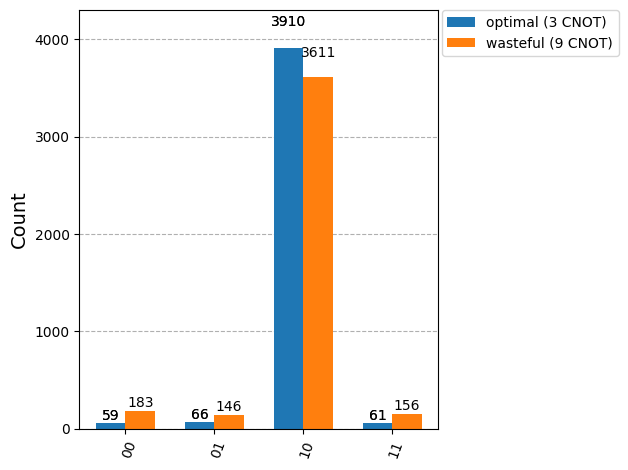

In [16]:
# A 2% depolarizing error on every CNOT, then a simulator that applies it.
noise = NoiseModel()
noise.add_all_qubit_quantum_error(depolarizing_error(0.02, 2), ["cx"])
sim = AerSimulator(noise_model=noise)

# Provided helper: prepare |01>, run `body`, measure. optimization_level=0 keeps the
# transpiler from tidying up the wasteful circuit's redundant CNOTs (otherwise its 9
# CNOTs collapse back to 3 and the comparison is meaningless).
def run_swap(body, shots=4096):
    qc = QuantumCircuit(2, 2)
    qc.x(0)                                   # prepare |..1> on qubit 0
    qc.compose(body, inplace=True)
    qc.measure([0, 1], [0, 1])
    tqc = transpile(qc, sim, optimization_level=0)
    return sim.run(tqc, shots=shots).result().get_counts()

# Run both circuits through the noisy simulator and plot the two histograms together.
counts_opt = run_swap(optimal)
counts_waste = run_swap(wasteful)
plot_histogram([counts_opt, counts_waste],
               legend=["optimal (3 CNOT)", "wasteful (9 CNOT)"])

The optimal circuit lands on the right answer far more sharply. Same unitary,
same hardware — the only difference is how many CNOTs the compiler spent. **This is why
decomposition quality matters**, and it's the same lesson as the bloated single-qubit
circuits from Lab 6, now in two-qubit form.

### 7b. Buying accuracy with CNOTs

Section 7a fixed the unitary and varied the *waste*. Now let's vary the **accuracy** on
purpose. The decomposer doesn't only build exact circuits — ask it for an `n`-CNOT circuit
when a gate really needs three, and it returns the *best possible approximation* at that
budget. Spending fewer CNOTs leaves you with some **synthesis error**: the circuit no
longer equals the gate you wanted.

How big is that error? Let's chart it. For each CNOT budget `n`, we'll take a batch of
random two-qubit gates, build the best `n`-CNOT approximation of each, score how faithful
it is with `gate_fidelity`, and average. The result is a clean cost-vs-accuracy curve — and
it's the **noiseless** baseline we'll need in 7c.

<b>Build the cost-vs-accuracy curve.</b> Set up a CNOT decomposer `cx_dec` and a list of
budgets `ns = [0, 1, 2, 3]`. Then, for each `n`: loop over ~40 random gates, decompose each
with exactly `n` CNOTs (`cx_dec(U, _num_basis_uses=n)`), measure `gate_fidelity` to the
target, and append the mean to a list `avg_fid`. Use those exact names — the provided plot
cell below reads `ns` and `avg_fid` to draw the curve (and 7c reuses them too).

In [17]:
# Sweep the CNOT budget and average the best achievable fidelity at each budget.
# Build cx_dec and ns, then fill avg_fid with one mean fidelity per budget.
cx_dec = TwoQubitBasisDecomposer(CXGate())
ns = [0, 1, 2, 3]                  # CNOT budgets to try
avg_fid = []
for n in ns:
    fids = []
    for s in range(40):
        U = random_unitary(4, seed=1000 + s).data
        approx = cx_dec(U, _num_basis_uses=n)   # best circuit with exactly n CNOTs
        fids.append(gate_fidelity(approx, U))   # 1.0 means it matched the target
    avg_fid.append(np.mean(fids))
for n, f in zip(ns, avg_fid):
    print(f"{n} CNOTs -> mean fidelity {f:.3f}")

0 CNOTs -> mean fidelity 0.509
1 CNOTs -> mean fidelity 0.813
2 CNOTs -> mean fidelity 0.978
3 CNOTs -> mean fidelity 1.000


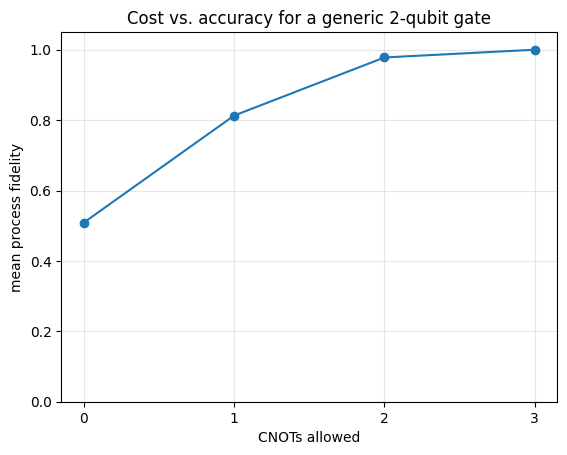

In [18]:
# Turn the table into a picture (uses ns and avg_fid from the cell above).
plt.plot(ns, avg_fid, "o-")
plt.xlabel("CNOTs allowed")
plt.ylabel("mean process fidelity")
plt.title("Cost vs. accuracy for a generic 2-qubit gate")
plt.xticks(ns)
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)
plt.show()

The curve climbs to the third CNOT, where it finally reaches fidelity 1 — the last gate
buys the final sliver of accuracy. But notice this whole picture is **noiseless**: it
charges you only for synthesis error, so it *always* says "spend all three CNOTs." Real
hardware disagrees, because — as 7a showed — every CNOT you run also injects noise. The
honest question is what happens when you put both effects on the same axes.

### 7c. The real trade-off: synthesis error vs. hardware error

Two error sources are now in play, and they pull in opposite directions:

* **Synthesis error** *shrinks* as you add CNOTs — more gates, better approximation (the
  7b curve).
* **Hardware error** *grows* as you add CNOTs — more gates, more noise (the 7a lesson).

The fidelity you actually achieve folds both together, so its peak can land at **fewer**
CNOTs than the exact decomposition. To see it, we need each approximate circuit's *noisy
channel*, not just its ideal unitary — and Aer will give us exactly that. Run a circuit
with `save_superop()` on an `AerSimulator(method="superop", ...)` and you get back the
`SuperOp` the noisy hardware would really apply; comparing that to the **target** `U` with
`process_fidelity` rolls synthesis and hardware error into a single number.

<b>Measure the true, noisy fidelity curve.</b> Use a noisier device this time — 5%
depolarizing error per CNOT, so the effect is easy to see. For each budget `n` in `ns`:
build the best `n`-CNOT approximation of each random gate, attach `save_superop()`, run the
batch on the superop simulator, and average `process_fidelity(channel, U)`. Collect the
means in a list named `noisy_fid` — match that name exactly, because the provided plot cell
overlays `noisy_fid` against the noiseless `avg_fid` from 7b (both indexed by `ns`).

In [19]:
# A noisier device: 5% depolarizing error per CNOT. The "superop" method lets us read out
# the exact noisy channel a circuit implements, so we can score it against the target gate.
NOISY_P = 0.05
nm = NoiseModel()
nm.add_all_qubit_quantum_error(depolarizing_error(NOISY_P, 2), ["cx"])
chan_sim = AerSimulator(method="superop", noise_model=nm)

noisy_fid = []
# For each budget n: collect the n-CNOT approximations, get their noisy channels in one
# batched run, and average the process fidelity to each target gate.
for n in ns:
    circs, targets = [], []
    for s in range(20):
        U = random_unitary(4, seed=1000 + s).data
        approx = cx_dec(U, _num_basis_uses=n)   # synthesis error lives here
        qc = approx.copy()
        qc.save_superop()                       # ask Aer for the realized noisy channel
        circs.append(qc)
        targets.append(U)
    result = chan_sim.run(circs).result()       # one batched simulation
    fids = [process_fidelity(result.data(i)["superop"], Operator(targets[i]))
            for i in range(len(circs))]
    noisy_fid.append(np.mean(fids))

for n, f in zip(ns, noisy_fid):
    print(f"{n} CNOTs -> mean fidelity on noisy hardware {f:.3f}")

0 CNOTs -> mean fidelity on noisy hardware 0.515
1 CNOTs -> mean fidelity on noisy hardware 0.781
2 CNOTs -> mean fidelity on noisy hardware 0.887
3 CNOTs -> mean fidelity on noisy hardware 0.866


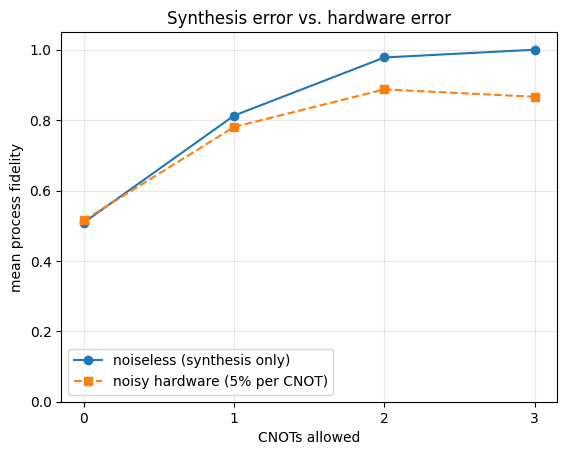

In [20]:
# Overlay the noiseless (synthesis-only) curve from 7b with the noisy one.
plt.plot(ns, avg_fid, "o-", label="noiseless (synthesis only)")
plt.plot(ns, noisy_fid, "s--", label=f"noisy hardware ({int(NOISY_P * 100)}% per CNOT)")
plt.xlabel("CNOTs allowed")
plt.ylabel("mean process fidelity")
plt.title("Synthesis error vs. hardware error")
plt.xticks(ns)
plt.ylim(0, 1.05)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

<div class="alert alert-success">

**What you should see**

The two curves part ways. The noiseless one keeps climbing to the third CNOT — if
synthesis error were all that mattered, you'd always buy the exact circuit. But the noisy
curve **turns over**: past two CNOTs, the hardware error from the extra gate outweighs the
sliver of accuracy it buys, so on this device the *best real circuit uses **fewer** CNOTs
than the exact decomposition.* That crossover is resource estimation in a nutshell — how
much to compile depends on how noisy your hardware is.

</div>


## Wrap-up

You can now take any two-qubit gate apart:

* **Every** two-qubit gate = single-qubit gates + CNOTs (the KAK decomposition), with all
  the entangling content packed into three Weyl coordinates $(a, b, c)$.
* A generic gate needs exactly **three CNOTs** — you can read the count straight off
  $(a, b, c)$ — which is why the SWAP from last lab costs three.
* The *native* gate (CNOT vs. iSWAP vs. RZZ) sets which resource you spend.
* On noisy hardware the two error sources fight: fewer CNOTs means more synthesis error but
  less hardware error, so the best *real* circuit can use **fewer** CNOTs than the exact
  decomposition.

This is the continuous cousin of the lab on **fault-tolerant compilation** (Lab 21):
there you chop a continuous *single-qubit* rotation into a discrete gate set and count
**T gates**; here you chop a continuous *two-qubit* gate into a native set and count
**CNOTs**. Same idea — compilation is decomposition, and the cost is the count.